# Flowers Recognition


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

100%|██████████| 225M/225M [00:00<00:00, 248MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2


In [2]:
import os

# List the contents of the dataset path to identify the subfolders
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print('{}{}/'.format(indent, os.path.basename(root)))
    if level > 1: # Limit depth for readability
        break

2/
    flowers/
        tulip/


In [3]:
import tensorflow as tf

# Define parameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# The dataset seems to be inside a 'flowers' subfolder within the downloaded path
data_dir = os.path.join(path, 'flowers') if 'flowers' in os.listdir(path) else path

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


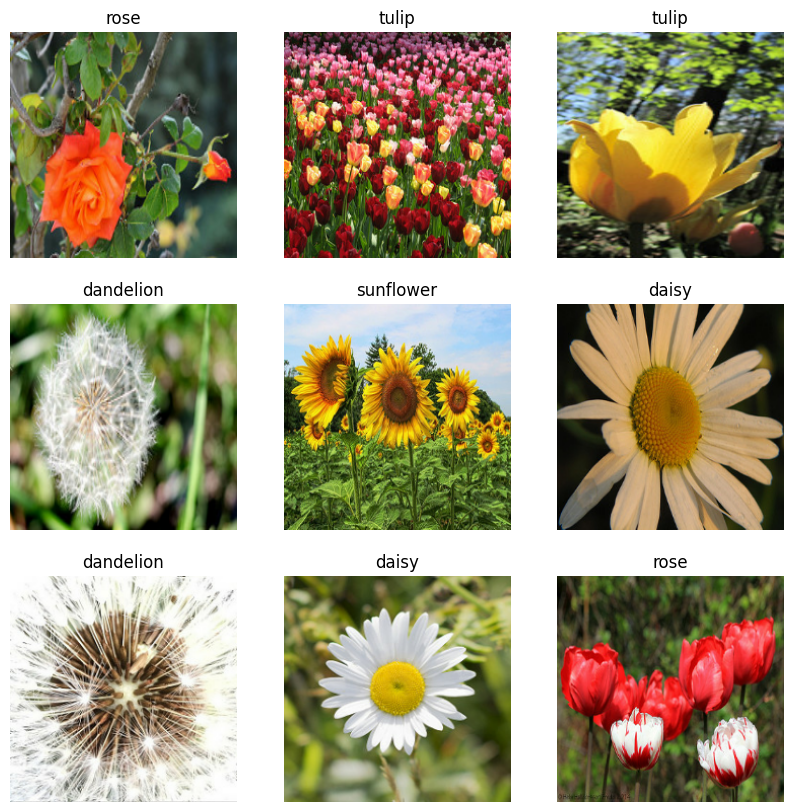

In [4]:
import matplotlib.pyplot as plt

# Visualize some samples
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [5]:
from tensorflow.keras.applications import ResNet50

In [6]:
based_model = ResNet50(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
based_model.trainable = True

In [8]:
for layer in based_model.layers[:-4]:
  layer.trainable = False

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout , Dense , Flatten ,Conv2D , MaxPool2D
from tensorflow.keras.optimizers import Adam


In [10]:
from tensorflow.keras.layers import GlobalAveragePooling2D

model = Sequential([
    based_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

In [11]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'],
              loss='sparse_categorical_crossentropy')

In [12]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 241ms/step - accuracy: 0.6766 - loss: 0.8801 - val_accuracy: 0.8320 - val_loss: 0.4761
Epoch 2/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.8581 - loss: 0.4201 - val_accuracy: 0.8610 - val_loss: 0.3897
Epoch 3/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.8966 - loss: 0.3031 - val_accuracy: 0.8621 - val_loss: 0.3699
Epoch 4/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.9213 - loss: 0.2404 - val_accuracy: 0.8714 - val_loss: 0.3610
Epoch 5/5
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.9459 - loss: 0.1756 - val_accuracy: 0.8772 - val_loss: 0.3566


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


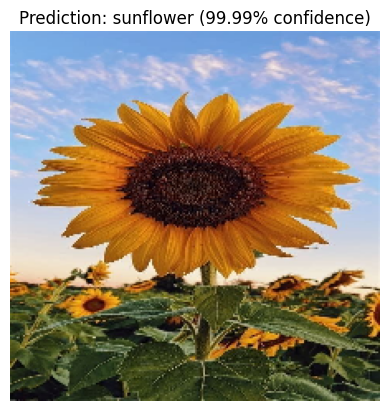

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to the specific image
img_path = '/content/sample_data/sun_flower.jpg'

# Load and preprocess the image
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Create a batch

# Make prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Display result
plt.imshow(img)
plt.title(f"Prediction: {class_names[np.argmax(predictions)]} ({100 * np.max(predictions):.2f}% confidence)")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


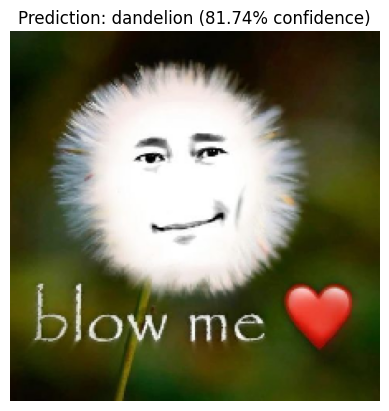

In [14]:
img_path = '/content/dandilion.jpg'

# Load and preprocess the image
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Create a batch

# Make prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Display result
plt.imshow(img)
plt.title(f"Prediction: {class_names[np.argmax(predictions)]} ({100 * np.max(predictions):.2f}% confidence)")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


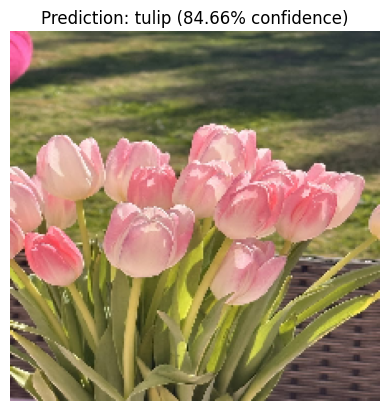

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


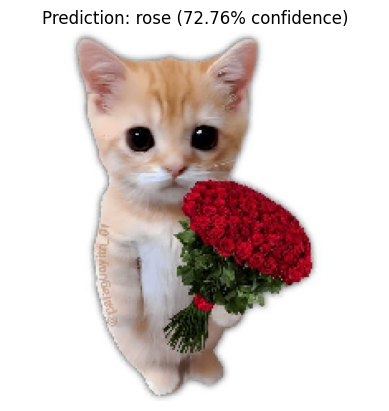

In [19]:
img_path = '/content/rose.jpg'

# Load and preprocess the image
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Create a batch

# Make prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Display result
plt.imshow(img)
plt.title(f"Prediction: {class_names[np.argmax(predictions)]} ({100 * np.max(predictions):.2f}% confidence)")
plt.axis('off')
plt.show()